# Hawkes Process Shock Propagation — Optuna-Tuned Discretisation & Decay

**Goal**: Model how market shocks propagate across macro series using a multivariate
Hawkes process (MHP) with exponential kernel, via the **Sparklen** library.

Optuna jointly optimises, per trial:
- a shared exponential decay `β` (1/day)
- per-column upper/lower tail quantile cut-points

by **maximising** `LearnerHawkesExp.score()` (negative LS contrast — higher is better).
The optimal `β` maps directly to polars EWM half-life for downstream feature engineering.

### Why Sparklen over tick?
tick uses MLE + BFGS and is tied to Intel MKL (uninstallable on ARM/Apple Silicon).
Sparklen uses **least-squares contrast** (Bacry et al. 2020) with AGD/FISTA, implemented
in portable C++ via SWIG.  For high-dimensional networks the LS loss is O(d³) per
gradient step — independent of event count — making it far faster than MLE at scale.

### Data flow
```
params.yaml sources           FRED (optional)
 V2TX · brent · eu_fx  ──►   VIX · EU HY OAS · ECB rate · US slope
 eu_uncertainty                          │
                                         ▼
                              daily master frame
                                         │
                    ┌────────────────────┴────────────────────┐
                    │  Optuna (TPE, multivariate, n=150)       │
                    │  search: decay β + {upper_q, lower_q}/col│
                    │  objective: LearnerHawkesExp.score()      │
                    └──────────────────────┬──────────────────┘
                                           │
                              best β · best cut-points
                                           │
                    ┌──────────────────────┴──────────────────┐
                    │  Final LearnerHawkesExp (Lasso + EBIC)   │
                    │  estimated_params → (μ, α)               │
                    └──────────────────────┬──────────────────┘
                                           │
                    α heatmap (shock network)   β → EWM features
                    pl.col(c).ewm_mean(half_life = ln2 / β)
```

In [42]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import sys, os, warnings, json, pathlib
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import yaml
import numpy as np                      # only at sparklen/matplotlib boundary
import polars as pl
import matplotlib.pyplot as plt

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sparklen.hawkes.inference import LearnerHawkesExp

# project helpers
from extract.io import execute_polars

print('polars', pl.__version__, '| optuna', optuna.__version__)

polars 1.38.1 | optuna 4.8.0


## 1 · Load data from `params.yaml` sources

In [43]:
with open(os.path.abspath('../params.yaml')) as f:
    params = yaml.safe_load(f)

print('sources:', list(params['sources'].keys()))

raw_sources: dict[str, pl.DataFrame] = {}

for src_name, cfg in params['sources'].items():
    if src_name == 'stock_history':
        continue
    print(f'Loading {src_name} …', end=' ', flush=True)
    try:
        df = execute_polars(cfg['polars'])
        if 'date' not in df.columns:
            print('⚠  no date column, skipping')
            continue
        raw_sources[src_name] = df.sort('date')
        print(f'✓  {df.shape}')
    except Exception as e:
        print(f'✗  {type(e).__name__}: {e}')

print(f'\nLoaded {len(raw_sources)} source(s):', list(raw_sources.keys()))

sources: ['eu_uncertainty', 'eu_fx', 'V2TX', 'brent', 'stock_history']
Loading eu_uncertainty … ✓  (351, 7)
Loading eu_fx … ✓  (6983, 18)
Loading V2TX … ✓  (6942, 2)
Loading brent … ⚠  no date column, skipping

Loaded 3 source(s): ['eu_uncertainty', 'eu_fx', 'V2TX']


## 2 · Optional FRED series (via `pandas_datareader`)

Free FRED access — no API key required through `pandas_datareader`.

In [44]:
from pandas_datareader import data as pdr
from functools import reduce

FRED_SERIES = {
    'VIXCLS':         'VIX',        # CBOE VIX
    'BAMLHE00EHY0EY': 'EU_HY_OAS',  # ICE BofA Euro HY OAS
    'ECBDFR':         'ECB_RATE',   # ECB deposit facility rate
    'T10Y2Y':         'US_SLOPE',   # US 10Y–2Y yield spread
}

fred_pieces: list[pl.DataFrame] = []
for ticker, col in FRED_SERIES.items():
    try:
        raw = pdr.DataReader(ticker, 'fred', start='2010-01-01')
        fred_pieces.append(
            pl.from_pandas(raw.reset_index())
            .rename({'DATE': 'date', ticker: col})
            .with_columns(pl.col.date.cast(pl.Date))
            .sort('date')
        )
        print(f'✓  FRED {ticker:<20} ({col})')
    except Exception as e:
        print(f'✗  FRED {ticker}: {e}')

fred_df = (
    reduce(lambda a, b: a.join(b, on='date', how='full', coalesce=True), fred_pieces).sort('date')
    if fred_pieces else None
)

✓  FRED VIXCLS               (VIX)
✗  FRED BAMLHE00EHY0EY: Unable to read URL: https://fred.stlouisfed.org/graph/fredgraph.csv?id=BAMLHE00EHY0EY
Response Text:
b'<!DOCTYPE html>\r\n<html lang="en">\r\n<head>\r\n    <meta charset="utf-8">\r\n    <meta http-equiv="X-UA-Compatible" content="IE=edge">\r\n    <meta name="viewport" content="width=device-width, initial-scale=1">\r\n    <title>Error - St. Louis Fed</title>\r\n    <meta name="description" content="">\r\n    <meta name="keywords" content="">    \r\n    <link rel="stylesheet" type="text/css" href="/assets/bootstrap/dist/css/bootstrap.min.css">\r\n    <link rel="stylesheet" type="text/css" href="/css/home.min.css?1553087253">\r\n    <link rel="stylesheet" type="text/css" href="/assets/fontawesome-free/css/all.min.css">\r\n    <link rel="stylesheet" type="text/css" href="/assets/select2/dist/css/select2.min.css">\r\n    <style>p {\r\n        margin-bottom: 1.5em;\r\n    }</style>\r\n</head>\r\n<body>\r\n<link rel="preconnect" href=

## 3 · Assemble daily master frame & select columns

In [45]:
def pick_v2tx(df):   return df.select('date', pl.col('V2TX'))
def pick_brent(df):  return df.select('date', pl.col([c for c in df.columns if c != 'date'][0]).alias('BRENT'))
def pick_fx(df, keep=('USD','GBP','CHF','JPY')):
    cols = [c for c in df.columns if any(k in c.upper() for k in keep)] or [c for c in df.columns if c != 'date'][:4]
    return df.select('date', *[pl.col(c).alias(f'FX_{c}') for c in cols[:4]])
def pick_uncertainty(df):
    num = [c for c in df.columns if c != 'date']
    pref = [c for c in num if any(k in c.lower() for k in ('germany','france','europe','eu'))]
    chosen = (pref or num)[:2]
    return df.select('date', *[pl.col(c).alias(f'UNC_{c}') for c in chosen])

pieces: list[pl.DataFrame] = []
if 'V2TX'          in raw_sources: pieces.append(pick_v2tx(raw_sources['V2TX']))
if 'brent'         in raw_sources: pieces.append(pick_brent(raw_sources['brent']))
if 'eu_fx'         in raw_sources: pieces.append(pick_fx(raw_sources['eu_fx']))
if 'eu_uncertainty' in raw_sources: pieces.append(pick_uncertainty(raw_sources['eu_uncertainty']))
if fred_df is not None:            pieces.append(fred_df)

if not pieces:
    raise RuntimeError('No data loaded – check source connectivity above.')

master = (
    reduce(lambda a, b: a.join(b, on='date', how='full', coalesce=True), pieces)
    .sort('date')
)
print('master:', master.shape, '|', master['date'].min(), '→', master['date'].max())

master: (8843, 11) | 1997-01-01 → 2026-04-13


In [47]:
# ── Select columns: daily series with >= MIN_OBS non-null observations ────────
MIN_OBS   = 500
N_MAX_COLS = 6      # 6 cols → 12 dims → 144 kernel parameters

priority = ['V2TX', 'BRENT', 'VIX', 'EU_HY_OAS', 'ECB_RATE', 'US_SLOPE']

candidates = [
    c for c in master.columns
    if c != 'date'
    and master[c].dtype.is_numeric()
    and master[c].drop_nulls().len() >= MIN_OBS
]

COLS = (
    [c for c in priority if c in candidates]
    + [c for c in candidates if c not in priority]
)[:N_MAX_COLS]

N_DIMS = 2 * len(COLS)    # upper-tail + lower-tail per column
print(f'Selected {len(COLS)} columns → {N_DIMS} Hawkes dimensions:')
for c in COLS:
    print(f'  {c:<25}  n={master[c].drop_nulls().len()}')

hawkes_df = (
    master
    .select('date', *COLS)
    .filter(~pl.all_horizontal(pl.col(c).is_null() for c in COLS))
    .sort('date')
)
print(f'\nhawkes_df: {hawkes_df.shape}')

Selected 6 columns → 12 Hawkes dimensions:
  V2TX                       n=6942
  VIX                        n=4121
  ECB_RATE                   n=5947
  US_SLOPE                   n=4071
  FX_USD                     n=6983
  FX_JPY                     n=6983

hawkes_df: (8764, 7)


## 4 · Discretisation helpers

For each column we produce two sorted arrays of **days-since-start** timestamps:

| stream | condition | interpretation |
|--------|-----------|----------------|
| `{col}▲` | `value > quantile(upper_q)` | positive shock / spike |
| `{col}▼` | `value < quantile(lower_q)` | negative shock / crash |

Both functions are **pure polars** internally; `.to_numpy()` only appears at the
sparklen interface boundary (sparklen's SWIG layer expects `np.ndarray`).

In [48]:
def events_from_col(df, col, upper_q, lower_q):
    sub        = df.select('date', col).drop_nulls()
    t0         = sub['date'].min()
    t          = (pl.col('date') - t0).dt.total_seconds() / 86_400.0
    hi, lo     = sub[col].quantile(upper_q), sub[col].quantile(lower_q)
    ev         = sub.select(
        t.filter(pl.col(col) > hi).sort().implode().alias('up'),
        t.filter(pl.col(col) < lo).sort().implode().alias('dn'),
    )
    return ev['up'][0].to_numpy(), ev['dn'][0].to_numpy()


def build_events(df, cols, upper_qs, lower_qs):
    t0    = df['date'].min()
    t_end = float((df['date'].max() - t0).days)
    t     = (pl.col('date') - t0).dt.total_seconds() / 86_400.0

    thr = df.select(
        *[pl.col(c).quantile(upper_qs[c]).alias(f'{c}_hi') for c in cols],
        *[pl.col(c).quantile(lower_qs[c]).alias(f'{c}_lo') for c in cols],
    ).row(0, named=True)

    ev = df.select(
        *[t.filter(pl.col(c).is_not_null() & pl.col(c).gt(thr[f'{c}_hi'])).sort().implode().alias(f'{c}_up') for c in cols],
        *[t.filter(pl.col(c).is_not_null() & pl.col(c).lt(thr[f'{c}_lo'])).sort().implode().alias(f'{c}_dn') for c in cols],
    )
    return (
        [ev[f'{c}_{d}'][0].to_numpy() for c in cols for d in ('up', 'dn')],
        [f'{c}\u25b2' if d == 'up' else f'{c}\u25bc' for c in cols for d in ('up', 'dn')],
        t_end,
    )


# ── Sanity check with default 90th/10th percentiles ──────────────────────────
DEFAULT_UQ = {c: 0.90 for c in COLS}
DEFAULT_LQ = {c: 0.10 for c in COLS}

_ev, _lbl, _t_end = build_events(hawkes_df, COLS, DEFAULT_UQ, DEFAULT_LQ)
print(f't_end = {_t_end:.0f} days\n')
for label, ev in zip(_lbl, _ev):
    print(f'  {label:<28}  {len(ev):>5} events')

t_end = 9961 days

  V2TX▲                           694 events
  V2TX▼                           694 events
  VIX▲                            412 events
  VIX▼                            409 events
  ECB_RATE▲                       588 events
  ECB_RATE▼                         0 events
  US_SLOPE▲                       404 events
  US_SLOPE▼                       399 events
  FX_USD▲                         697 events
  FX_USD▼                         698 events
  FX_JPY▲                         698 events
  FX_JPY▼                         697 events


## 5 · Optuna optimisation

### Objective: maximise `LearnerHawkesExp.score(data, T)`

`score()` returns the **negative LS contrast** (higher = better fit).  
The paper (Section 4) recommends iterating over a β grid and keeping the best — Optuna
does this more efficiently with TPE, also coupling β with the cut-point search.

### Search space
| parameter | range | scale |
|-----------|-------|-------|
| `decay` β | [0.002, 3.0] 1/day | log (~2y → 5h half-life) |
| `{col}_upper_q` | [0.75, 0.995] | linear |
| `{col}_lower_q` | [0.005, 0.25] | linear |

> `multivariate=True` in TPESampler lets Optuna learn correlations between β and
> cut-points — critical here because a fast decay works best with denser event streams.

In [49]:
MIN_EVENTS_PER_DIM = 8
PENALTY            = -1e6


def hawkes_objective(trial: optuna.Trial) -> float:
    # ── 1. Sample ─────────────────────────────────────────────────────────────
    decay     = trial.suggest_float('decay', 0.002, 3.0, log=True)
    upper_qs  = {c: trial.suggest_float(f'{c}_upper_q', 0.75, 0.995) for c in COLS}
    lower_qs  = {c: trial.suggest_float(f'{c}_lower_q', 0.005, 0.25)  for c in COLS}

    # ── 2. Build event streams ────────────────────────────────────────────────
    events, _, t_end = build_events(hawkes_df, COLS, upper_qs, lower_qs)
    if any(len(e) < MIN_EVENTS_PER_DIM for e in events):
        return PENALTY

    # ── 3. Fit sparklen ───────────────────────────────────────────────────────
    # sparklen expects: list[list[ndarray]]
    #   outer list = n_samples repetitions  (we have 1: the full market history)
    #   inner list = d dimensions           (2 * len(COLS))
    data = [events]

    try:
        learner = LearnerHawkesExp(
            decay=decay,
            loss='least-squares',
            penalty='none',          # no regularisation during search
            optimizer='agd',
            lr_scheduler='backtracking',
            max_iter=200,
            tol=1e-5,
            verbose_bar=False,
            verbose=False,
        )
        learner.fit(data, t_end)
        score = learner.score(data, t_end)   # negative LS contrast → maximise
    except Exception:
        return PENALTY

    trial.set_user_attr('n_events', [int(len(e)) for e in events])
    trial.set_user_attr('score',    float(score))
    return float(score)


print('Objective defined.')

Objective defined.


In [50]:
N_TRIALS = 150

study = optuna.create_study(
    study_name='hawkes_optuna',
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
)

# Warm-start: 90th/10th default is a reasonable prior
study.enqueue_trial({
    'decay': 0.05,
    **{f'{c}_upper_q': 0.90 for c in COLS},
    **{f'{c}_lower_q': 0.10 for c in COLS},
})

study.optimize(hawkes_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\n✓  Best score  : {study.best_value:.6f}')
print(f'   Best decay β: {study.best_params["decay"]:.6f}  (1/day)')

Best trial: 81. Best value: -0.0489063: 100%|██████████| 150/150 [00:10<00:00, 14.13it/s]



✓  Best score  : -0.048906
   Best decay β: 2.869046  (1/day)


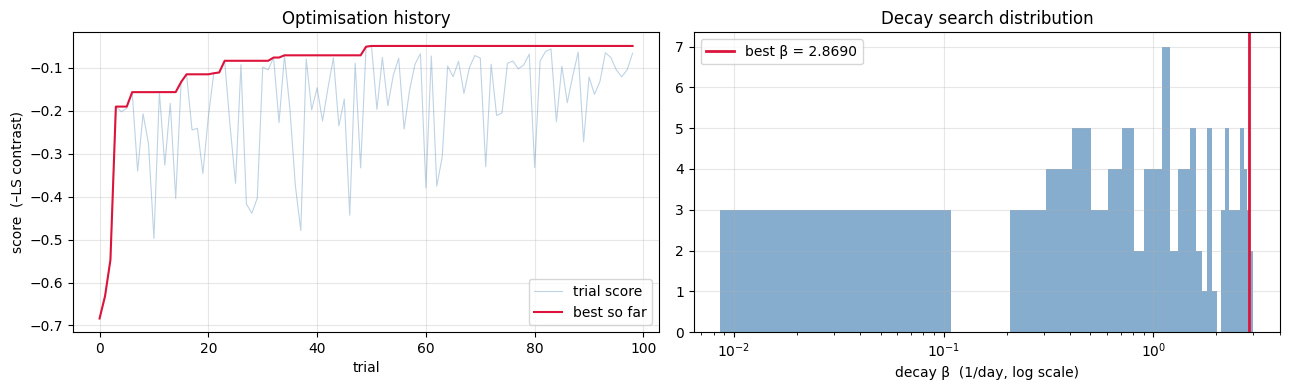

In [51]:
# ── Optuna diagnostics ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

values        = [t.value for t in study.trials if t.value and t.value > PENALTY]
best_so_far   = np.maximum.accumulate(values)
axes[0].plot(values, alpha=0.35, lw=0.8, color='steelblue', label='trial score')
axes[0].plot(best_so_far, color='crimson', lw=1.5, label='best so far')
axes[0].set(xlabel='trial', ylabel='score  (–LS contrast)', title='Optimisation history')
axes[0].legend(); axes[0].grid(alpha=0.3)

decays = [t.params['decay'] for t in study.trials if t.value and t.value > PENALTY]
axes[1].hist(decays, bins=30, color='steelblue', alpha=0.65)
axes[1].axvline(study.best_params['decay'], color='crimson', lw=2,
                label=f'best β = {study.best_params["decay"]:.4f}')
axes[1].set_xscale('log')
axes[1].set(xlabel='decay β  (1/day, log scale)', title='Decay search distribution')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 6 · Final model

Refit with the best parameters, this time using **Lasso + EBIC** to regularise
the interaction matrix — EBIC is more consistent than CV for sparse support recovery
(see Section 3.3 and Figure 8 of the sparklen paper).

In [52]:
best = study.best_params

BEST_DECAY    = best['decay']
BEST_UPPER_QS = {c: best[f'{c}_upper_q'] for c in COLS}
BEST_LOWER_QS = {c: best[f'{c}_lower_q'] for c in COLS}

print(f'Optimal decay β = {BEST_DECAY:.6f}  (1/day)')
print(f'Half-life       = {np.log(2)/BEST_DECAY:.1f}  days\n')
print('Cut-points:')
for c in COLS:
    hi = float(hawkes_df[c].drop_nulls().quantile(BEST_UPPER_QS[c]))
    lo = float(hawkes_df[c].drop_nulls().quantile(BEST_LOWER_QS[c]))
    print(f'  {c:<25}  ▲ q={BEST_UPPER_QS[c]:.3f} ({hi:+.4g})   '
          f'▼ q={BEST_LOWER_QS[c]:.3f} ({lo:+.4g})')

Optimal decay β = 2.869046  (1/day)
Half-life       = 0.2  days

Cut-points:
  V2TX                       ▲ q=0.917 (+36.8)   ▼ q=0.043 (+13.09)
  VIX                        ▲ q=0.933 (+29.52)   ▼ q=0.140 (+12.73)
  ECB_RATE                   ▲ q=0.816 (+2)   ▼ q=0.206 (-0.4)
  US_SLOPE                   ▲ q=0.846 (+2.12)   ▼ q=0.040 (-0.59)
  FX_USD                     ▲ q=0.921 (+1.401)   ▼ q=0.078 (+0.9542)
  FX_JPY                     ▲ q=0.859 (+157.5)   ▼ q=0.011 (+96.03)


In [33]:
final_events, DIM_LABELS, t_end = build_events(
    hawkes_df, COLS, BEST_UPPER_QS, BEST_LOWER_QS
)
data_final = [final_events]   # 1 repetition (single long market path)

final_learner = LearnerHawkesExp(
    decay=BEST_DECAY,
    loss='least-squares',
    penalty='lasso',
    kappa_choice='ebic',   # EBIC for principled sparsity selection
    optimizer='agd',
    lr_scheduler='backtracking',
    max_iter=500,
    tol=1e-5,
    verbose_bar=True,
    verbose=False,
)
final_learner.fit(data_final, t_end)

print(f'\nFinal score : {final_learner.score(data_final, t_end):.6f}')
print(f'Total events: {sum(len(e) for e in final_events)}')


Best kappa found: 0.0 with score: 48428.954470310375



Time elapsed: 0.08 seconds.


Searching: 100%|██████████| 20/20 [00:00<00:00, 256.81it/s]



Best kappa found: 0.0 with score: 48428.954470310375



Time elapsed: 0.00 seconds.


Refined Searching: 100%|██████████| 10/10 [00:00<00:00, 1511.24it/s]



Optimization completed. Convergence achieved after 47 iterations.



Time elapsed: 0.03 seconds.


Optimizing:  10%|█         | 50/500 [00:00<00:00, 14131.75it/s]



Final score : -0.048906
Total events: 6570


In [34]:
# ── Extract parameters ────────────────────────────────────────────────────────
# estimated_params shape: (N_DIMS, N_DIMS + 1)
#   col 0    → μ  (baseline intensity vector)
#   cols 1:  → α  (interaction / kernel matrix)
params_hat = final_learner.estimated_params
mu    = params_hat[:, 0]    # (N_DIMS,)
alpha = params_hat[:, 1:]   # (N_DIMS, N_DIMS)  α[i,j] = excitation j→i

## 7 · Shock propagation analysis

`α[i, j]` = expected number of extra events in stream `i` triggered by one event in `j`.  
Blocks of size 2×2 correspond to the same underlying asset (▲▼).

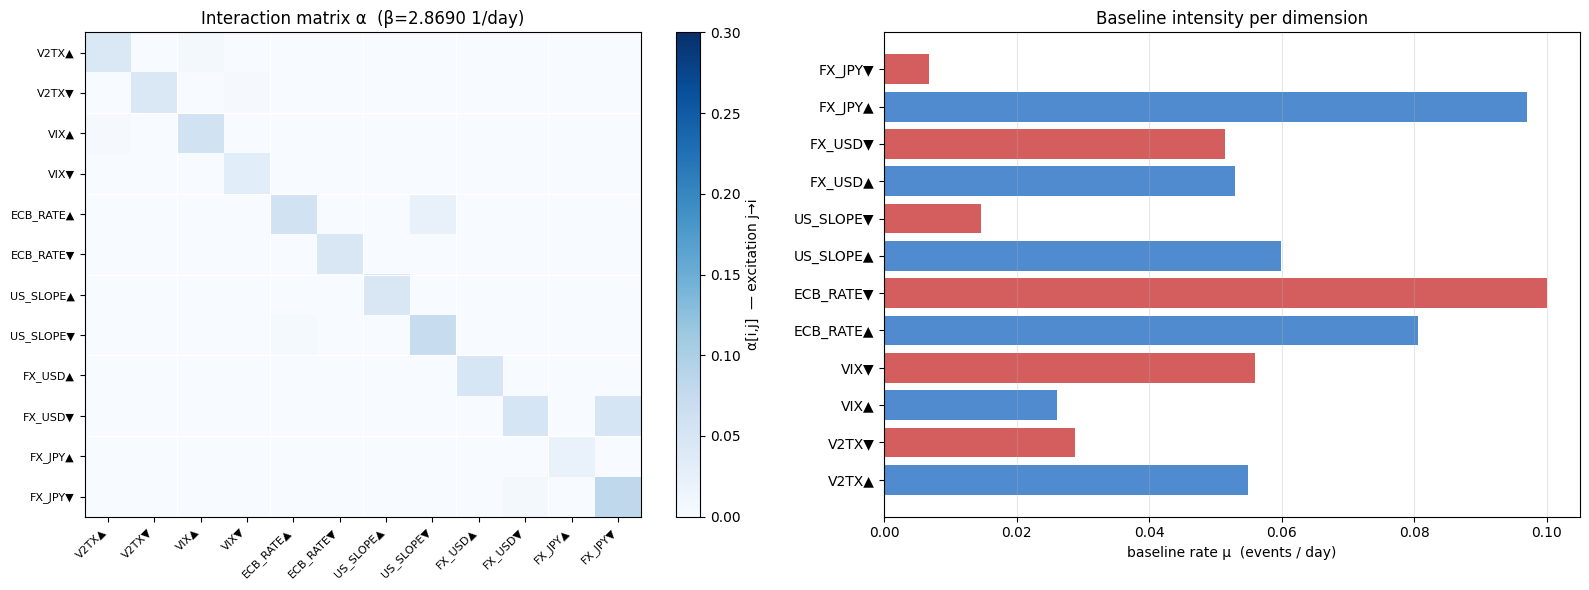

Top-10 cross-asset excitation pairs (j → i):
  FX_JPY▼                → FX_USD▼                 α = 0.0494
  US_SLOPE▼              → ECB_RATE▲               α = 0.0217
  VIX▲                   → V2TX▲                   α = 0.0062
  FX_USD▼                → FX_JPY▼                 α = 0.0060
  ECB_RATE▲              → US_SLOPE▼               α = 0.0039
  VIX▼                   → V2TX▼                   α = 0.0028
  V2TX▲                  → VIX▲                    α = 0.0028
  V2TX▼                  → VIX▼                    α = 0.0007
  FX_JPY▲                → VIX▼                    α = 0.0000
  FX_USD▼                → VIX▼                    α = 0.0000


In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── α heatmap ─────────────────────────────────────────────────────────────────
ax = axes[0]
vmax = max(alpha.max(), 0.3)
im   = ax.imshow(alpha, cmap='Blues', aspect='auto', vmin=0, vmax=vmax)
ax.set_xticks(range(N_DIMS)); ax.set_xticklabels(DIM_LABELS, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(N_DIMS)); ax.set_yticklabels(DIM_LABELS, fontsize=8)
ax.set_title(f'Interaction matrix α  (β={BEST_DECAY:.4f} 1/day)')
plt.colorbar(im, ax=ax, label='α[i,j]  — excitation j→i')
for k in range(0, N_DIMS + 1, 2):     # asset-block grid lines
    ax.axhline(k - 0.5, color='white', lw=0.8)
    ax.axvline(k - 0.5, color='white', lw=0.8)

# ── μ baseline bars ───────────────────────────────────────────────────────────
ax2 = axes[1]
colors = ['#1565C0' if '▲' in l else '#C62828' for l in DIM_LABELS]
ax2.barh(DIM_LABELS, mu, color=colors, alpha=0.75)
ax2.set_xlabel('baseline rate μ  (events / day)')
ax2.set_title('Baseline intensity per dimension')
ax2.grid(alpha=0.3, axis='x')

plt.tight_layout(); plt.show()

# ── Top cross-dim excitations ─────────────────────────────────────────────────
print('Top-10 cross-asset excitation pairs (j → i):')
shown = 0
for flat in np.argsort(alpha.ravel())[::-1][:30]:
    i, j = flat // N_DIMS, flat % N_DIMS
    if i != j:
        print(f'  {DIM_LABELS[j]:<22} → {DIM_LABELS[i]:<22}  α = {alpha[i,j]:.4f}')
        shown += 1
    if shown >= 10:
        break

In [35]:
# ── Spectral radius & branching ratios ────────────────────────────────────────
spectral_radius = float(np.max(np.abs(np.linalg.eigvals(alpha))))
row_sums        = alpha.sum(axis=1)    # total excitation received by each dim

print(f'Spectral radius ρ(α) = {spectral_radius:.4f}  '
      f'({"✓ stationary" if spectral_radius < 1 else "⚠ non-stationary — consider tighter cut-points"})')
print('\nBranching ratios (triggered fraction):')
for lbl, rs in zip(DIM_LABELS, row_sums):
    bar = '█' * int(rs * 40)
    print(f'  {lbl:<25}  {rs:.3f}  {bar}')

Spectral radius ρ(α) = 0.0893  (✓ stationary)

Branching ratios (triggered fraction):
  V2TX▲                      0.051  ██
  V2TX▼                      0.047  █
  VIX▲                       0.059  ██
  VIX▼                       0.033  █
  ECB_RATE▲                  0.079  ███
  ECB_RATE▼                  0.045  █
  US_SLOPE▲                  0.045  █
  US_SLOPE▼                  0.076  ███
  FX_USD▲                    0.049  █
  FX_USD▼                    0.100  ████
  FX_JPY▲                    0.020  
  FX_JPY▼                    0.088  ███


## 7b · Per-column decay calibration

The multivariate model shares a single `β` (required by Sparklen's LS loss), but each
series has its own natural shock timescale — volatility indices revert in days, policy
rates in weeks.  We run a lightweight **univariate** Optuna search per Hawkes dimension,
reusing the already-optimal cut-points, to get per-column half-lives for EWM features.

In [36]:
N_TRIALS_1D = 50

def hawkes_obj_1d(trial, events_1d, t_end_val):
    decay = trial.suggest_float('decay', 0.002, 3.0, log=True)
    if len(events_1d) < MIN_EVENTS_PER_DIM:
        return PENALTY
    try:
        lrn = LearnerHawkesExp(
            decay=decay, loss='least-squares', penalty='none',
            optimizer='agd', lr_scheduler='backtracking',
            max_iter=200, tol=1e-5, verbose_bar=False, verbose=False,
        )
        lrn.fit([[events_1d]], t_end_val)
        return lrn.score([[events_1d]], t_end_val)
    except Exception:
        return PENALTY


print('Per-dimension \u03b2 (warm-started from multivariate best):')
BEST_DECAYS_PER_DIM: dict[str, float] = {}

for label, ev in zip(DIM_LABELS, final_events):
    s = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
    s.enqueue_trial({'decay': BEST_DECAY})
    s.optimize(lambda trial, e=ev, t=t_end: hawkes_obj_1d(trial, e, t),
               n_trials=N_TRIALS_1D, show_progress_bar=False)
    BEST_DECAYS_PER_DIM[label] = s.best_params['decay']
    hl = np.log(2) / BEST_DECAYS_PER_DIM[label]
    print(f'  {label:<28}  \u03b2={BEST_DECAYS_PER_DIM[label]:.5f}  hl={hl:5.1f} d')

## 8 · Feature engineering: EWM from optimal β

The exponential kernel `α·β·exp(−β·Δt)` is the impulse response of a
single-pole EWM filter.  Matching the filter to the Hawkes excitation gives:

```
half_life  =  ln(2) / β          (days)
alpha_ema  =  1 − exp(−β)        (per-day smoothing factor for polars)
```

Plugging the Optuna-optimal `β` into `pl.col(c).ewm_mean(half_life=...)` gives
a data-driven, principled EWM window anchored to how fast shocks actually decay
in this market.

In [37]:
print(f'  {"dim":<28}  {"\u03b2 (1/day)":>12}  {"half-life (d)":>14}  {"\u03b1_ema":>9}')
print('\u2500' * 70)
for dim, b in BEST_DECAYS_PER_DIM.items():
    hl = np.log(2) / b
    print(f'  {dim:<28}  {b:>12.6f}  {hl:>14.2f}  {1 - np.exp(-b):>9.6f}')
print(f'\n  shared \u03b2 (multivariate) = {BEST_DECAY:.6f}  (hl = {np.log(2)/BEST_DECAY:.1f} d)')

In [38]:
def hawkes_ewm_exprs(dim_labels, betas):
    """
    Per-dimension EWM expressions (mean, std, z-score) in one list.
    dim_labels : e.g. ['V2TX\u25b2', 'V2TX\u25bc', ...]
    betas      : dict dim_label -> \u03b2  (per-dim decay from univariate fit)
    All three expressions for a given dim share the same half_life and reference
    the underlying col directly, so a single with_columns call suffices.
    """
    exprs = []
    for dim in dim_labels:
        col = dim[:-1]          # strip \u25b2/\u25bc
        hl  = np.log(2) / betas[dim]
        m   = pl.col(col).ewm_mean(half_life=hl)
        s   = pl.col(col).ewm_std(half_life=hl)
        exprs += [
            m.alias(f'{dim}_ewm'),
            s.alias(f'{dim}_ewm_std'),
            ((pl.col(col) - m) / s.clip(lower_bound=1e-8)).alias(f'{dim}_ewm_z'),
        ]
    return exprs


ewm_df = hawkes_df.with_columns(*hawkes_ewm_exprs(DIM_LABELS, BEST_DECAYS_PER_DIM))
print('EWM feature frame:', ewm_df.shape)
ewm_df.select('date', *[f'{d}_ewm_z' for d in DIM_LABELS]).tail(5)

In [39]:
# alpha[i,j] = excitation j -> i  (N_DIMS x N_DIMS, already dim-aligned)
row_totals  = alpha.sum(axis=1, keepdims=True)
alpha_w     = np.where(row_totals > 0, alpha / row_totals, 1.0 / N_DIMS)

z_matrix    = ewm_df.select([f'{d}_ewm_z' for d in DIM_LABELS]).to_numpy()
z_net       = z_matrix @ alpha_w.T

ewm_df = ewm_df.with_columns(
    [pl.Series(f'{d}_net_z', z_net[:, i]) for i, d in enumerate(DIM_LABELS)]
)

# causal weight summary
print('Causal weight matrix \u03b1_w[i ← j]:')
header = f'  {"":>22}' + ''.join(f'  {d:>16}' for d in DIM_LABELS)
print(header)
for i, d_i in enumerate(DIM_LABELS):
    row = f'  {d_i:<22}' + ''.join(f'  {alpha_w[i,j]:>16.4f}' for j in range(N_DIMS))
    print(row)
ewm_df.select('date', *[f'{d}_net_z' for d in DIM_LABELS]).tail(3)

In [40]:
n_cols_plot = 2    # ▲ and ▼ side by side per underlying asset
fig, axes   = plt.subplots(len(COLS), n_cols_plot * 2,
                            figsize=(18, 2.2 * len(COLS)), sharex=True)
if len(COLS) == 1:
    axes = axes.reshape(1, -1)

dates_pd = ewm_df['date'].to_pandas()

for row_i, c in enumerate(COLS):
    for col_i, tail in enumerate(('\u25b2', '\u25bc')):
        dim     = f'{c}{tail}'
        hl      = np.log(2) / BEST_DECAYS_PER_DIM[dim]
        z_own   = ewm_df[f'{dim}_ewm_z'].to_numpy()
        z_net   = ewm_df[f'{dim}_net_z'].to_numpy()
        for ax_i, (z, label) in enumerate([(z_own, f'own  hl={hl:.0f}d'), (z_net, 'network')]):
            ax = axes[row_i, col_i * 2 + ax_i]
            ax.fill_between(dates_pd, z, 0, where=z > 0, color='#1565C0', alpha=0.5)
            ax.fill_between(dates_pd, z, 0, where=z < 0, color='#C62828', alpha=0.5)
            ax.axhline(0, color='black', lw=0.4)
            ax.grid(alpha=0.2)
            if row_i == 0:
                ax.set_title(f'{dim}  {label}', fontsize=8)
            if col_i == 0 and ax_i == 0:
                ax.set_ylabel(c, fontsize=8)

axes[-1, 0].set_xlabel('date')
plt.tight_layout()
plt.show()

print('BEST_DECAYS_PER_DIM =', {k: round(v, 6) for k, v in BEST_DECAYS_PER_DIM.items()})

In [41]:
OUT = pathlib.Path('../research')

results = {
    'best_decay_per_day':      BEST_DECAY,
    'best_decays_per_dim':     BEST_DECAYS_PER_DIM,
    'spectral_radius':         spectral_radius,
    'cols':                    COLS,
    'dim_labels':              DIM_LABELS,
    'best_upper_qs':           BEST_UPPER_QS,
    'best_lower_qs':           BEST_LOWER_QS,
    'mu':                      mu.tolist(),
    'alpha':                   alpha.tolist(),
    'alpha_w':                 alpha_w.tolist(),
    'branching_ratios':        dict(zip(DIM_LABELS, row_sums.tolist())),
    'optuna_best_score':       study.best_value,
    'n_trials':                len(study.trials),
    'top_cross_excitations': [
        {'from': DIM_LABELS[j], 'to': DIM_LABELS[i], 'alpha': float(alpha[i, j])}
        for i, j in sorted(
            [(f // N_DIMS, f % N_DIMS) for f in np.argsort(alpha.ravel())[::-1][:30]],
            key=lambda ij: -alpha[ij[0], ij[1]]
        )
        if i != j
    ][:10],
}

(OUT / 'hawkes_optuna_results.json').write_text(json.dumps(results, indent=2))
ewm_df.write_parquet(str(OUT / 'hawkes_ewm_features.parquet'))
print('\u2713  hawkes_optuna_results.json')
print('\u2713  hawkes_ewm_features.parquet')
print(f'   features: {[c for c in ewm_df.columns if c != "date"]}')